<a href="https://colab.research.google.com/github/Ahmadfarkhani0805/2025_Pengolahan_Citra_TI-2A/blob/main/Jobsheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

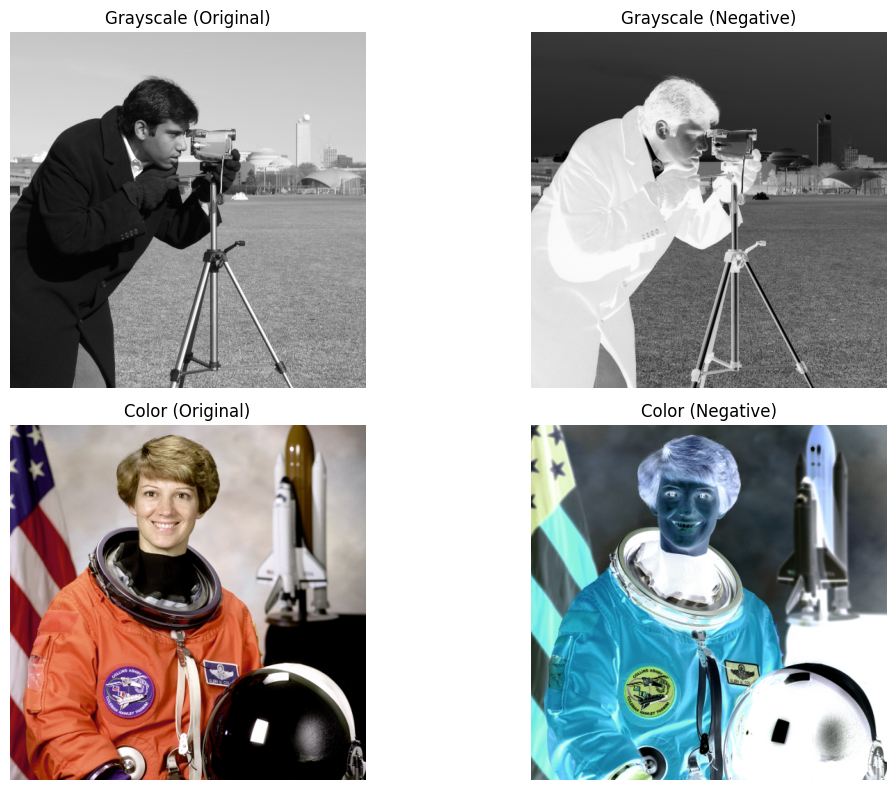

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


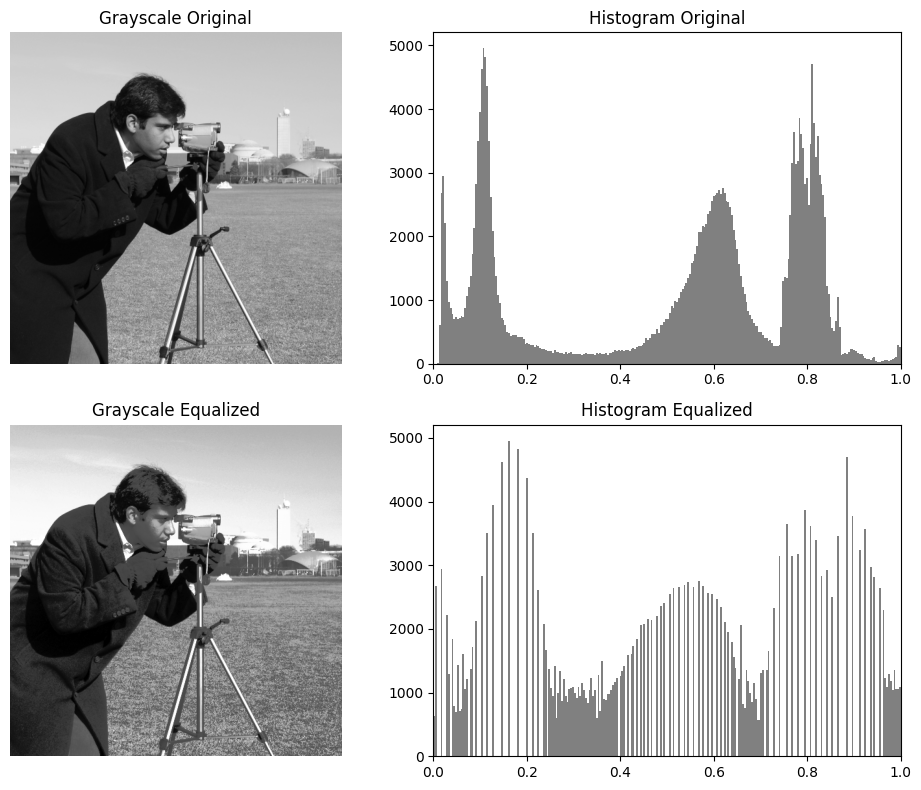

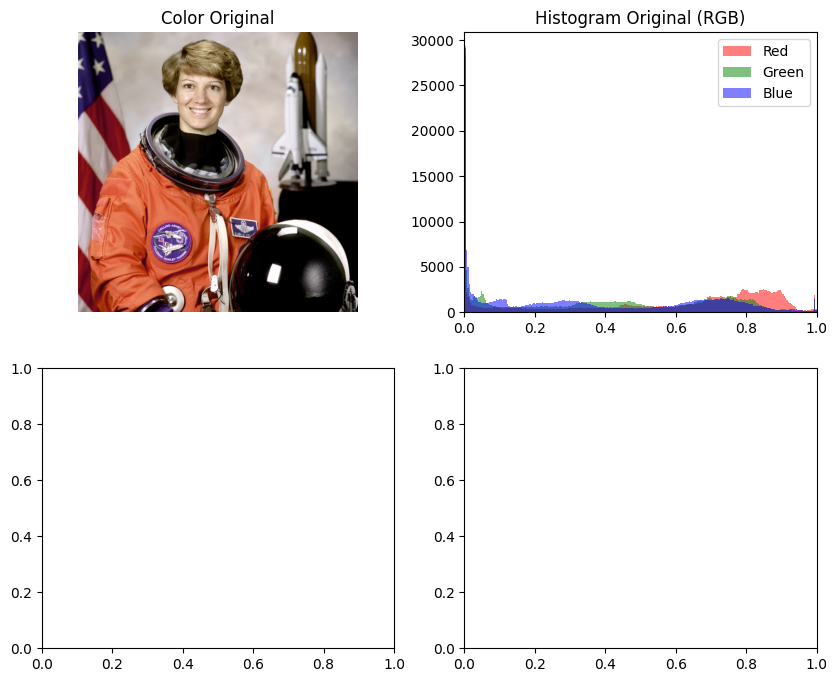

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# ========================
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# ========================

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # Sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

# 2. Menghitung histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

# ========================
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# ========================

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # Citra berwarna RGB (uint8)
image_color = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

# 2. Ambil masing-masing kanal warna
r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

# Hitung histogram untuk tiap kanal
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram per kanal
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan menjadi citra RGB hasil ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram citra ekualisasi per kanal
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

# 4. Plot citra warna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

# (


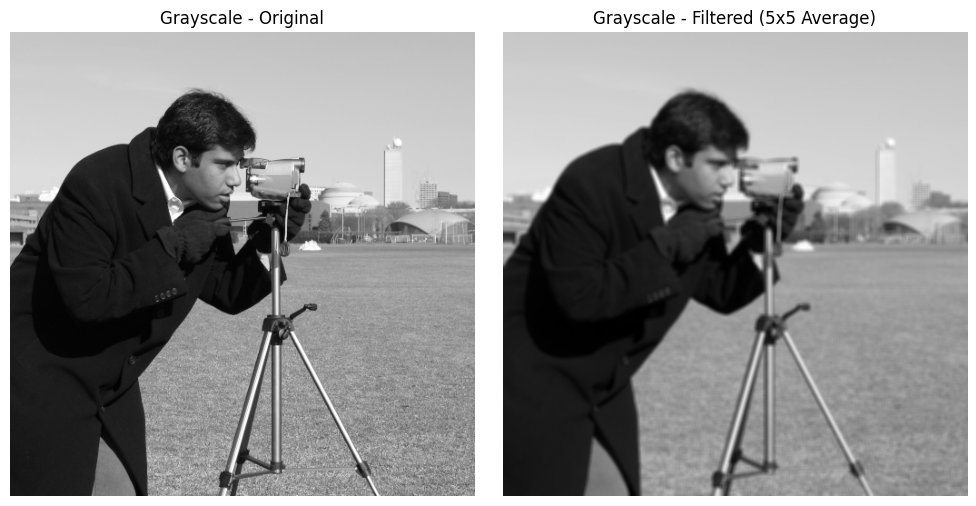

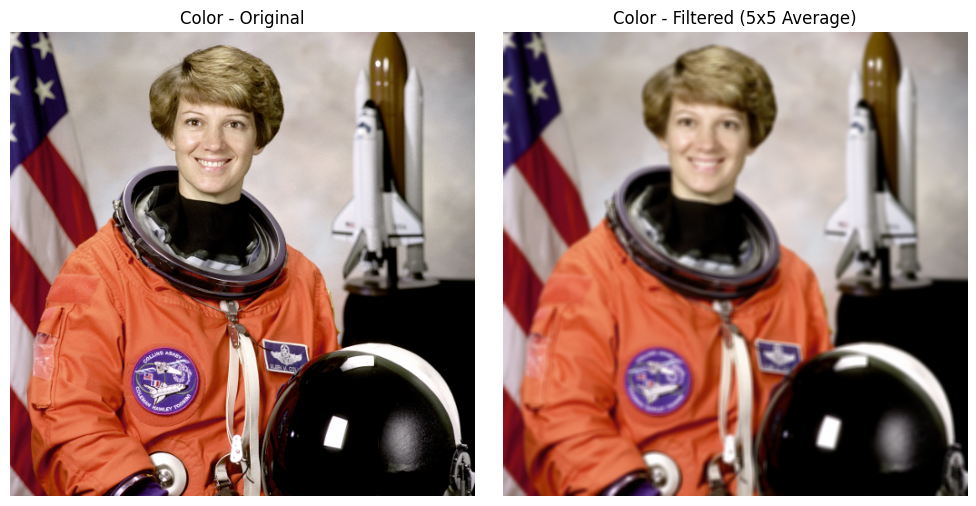

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# ============================
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# ============================

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1]

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ============================
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# ============================

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi ke float [0..1]

# B. Terapkan filter rata-rata per kanal (R, G, B)
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

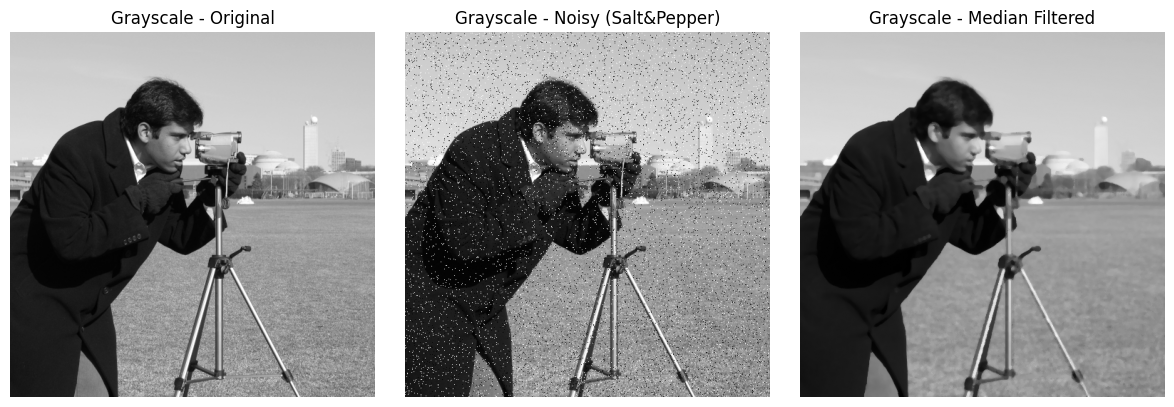

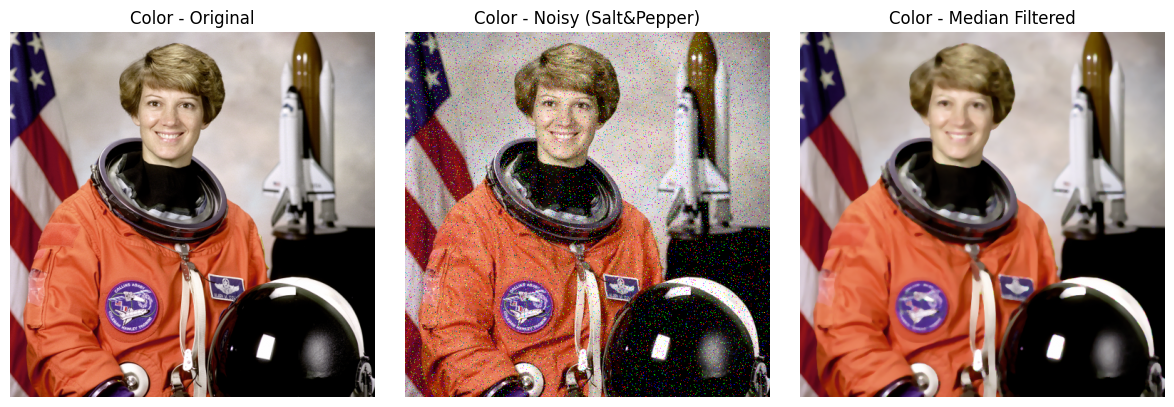

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

#
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
#

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()  # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)  # 5% piksel terpengaruh noise

# C. Menerapkan filter median
# Gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

#
# 2) FILTER MEDIAN PADA CITRA BERWARNA
#

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()  # RGB, uint8
color_float = img_as_float(color_uint8)  # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
# Kita lakukan per kanal (R, G, B)
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


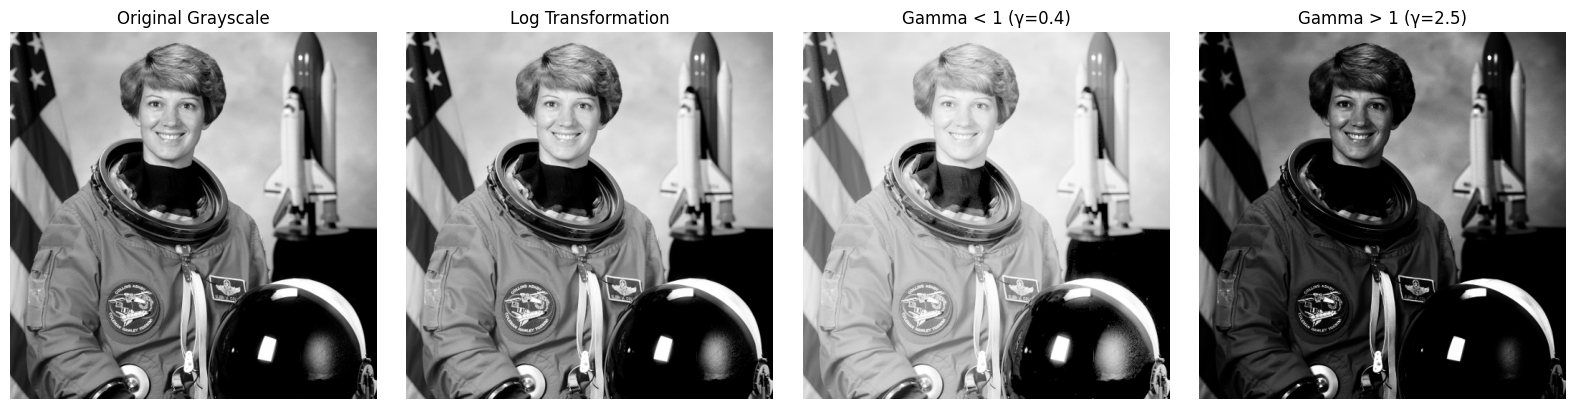

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# 1. Memuat citra RGB dan mengubah ke grayscale
image_rgb = data.astronaut()
image_gray = color.rgb2gray(image_rgb)  # hasil sudah dalam float [0..1]

# 2. Transformasi logaritmik
log_transformed = exposure.adjust_log(image_gray, gain=1)  # c bisa diset melalui 'gain'

# 3. Transformasi gamma (dengan beberapa nilai gamma)
gamma_low = exposure.adjust_gamma(image_gray, gamma=0.4, gain=1)
gamma_high = exposure.adjust_gamma(image_gray, gamma=2.5, gain=1)

# 4. Plot semua hasil
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(log_transformed, cmap='gray')
axes[1].set_title("Log Transformation")
axes[1].axis('off')

axes[2].imshow(gamma_low, cmap='gray')
axes[2].set_title("Gamma < 1 (γ=0.4)")
axes[2].axis('off')

axes[3].imshow(gamma_high, cmap='gray')
axes[3].set_title("Gamma > 1 (γ=2.5)")
axes[3].axis('off')

plt.tight_layout()
plt.show()


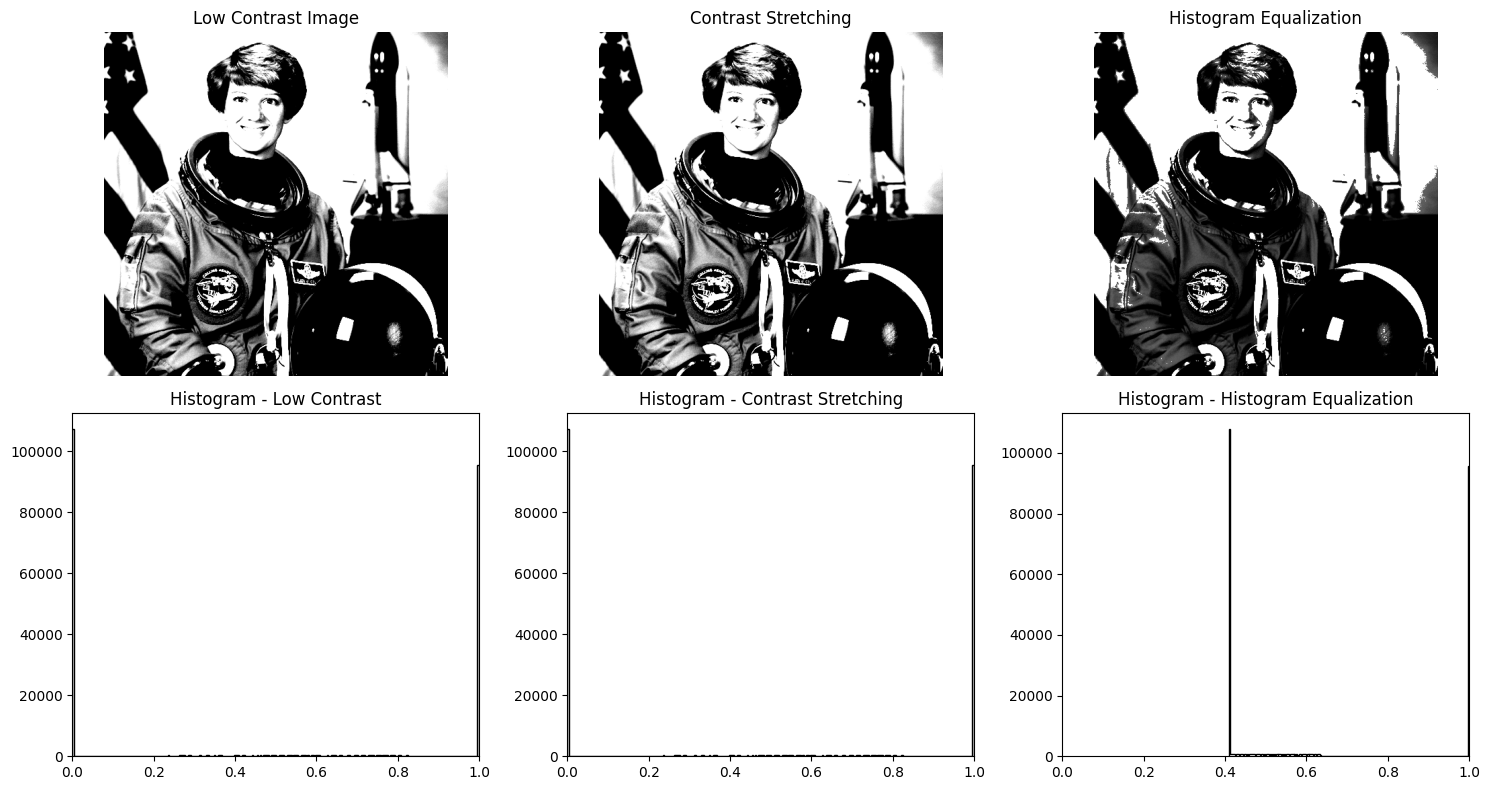

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# 1. Ambil dan ubah citra ke grayscale
image_rgb = data.astronaut()
image_gray = color.rgb2gray(image_rgb)  # skala [0..1]

# 2. Simulasikan citra kontras rendah (dipersempit rentang intensitas)
low_contrast = exposure.rescale_intensity(image_gray, in_range=(0.4, 0.6))  # rentang intensitas disempitkan

# 3. Contrast stretching (mengembalikan ke [0,1])
contrast_stretched = exposure.rescale_intensity(low_contrast, in_range='image', out_range=(0, 1))

# 4. Histogram equalization
hist_eq = exposure.equalize_hist(low_contrast)

# 5. Fungsi bantu untuk plotting histogram
def plot_hist(image, ax, title):
    ax.hist(image.ravel(), bins=256, histtype='step', color='black')
    ax.set_title(title)
    ax.set_xlim(0, 1)

# 6. Plot hasil citra
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title("Low Contrast Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(contrast_stretched, cmap='gray')
axes[0, 1].set_title("Contrast Stretching")
axes[0, 1].axis('off')

axes[0, 2].imshow(hist_eq, cmap='gray')
axes[0, 2].set_title("Histogram Equalization")
axes[0, 2].axis('off')

plot_hist(low_contrast, axes[1, 0], "Histogram - Low Contrast")
plot_hist(contrast_stretched, axes[1, 1], "Histogram - Contrast Stretching")
plot_hist(hist_eq, axes[1, 2], "Histogram - Histogram Equalization")

plt.tight_layout()
plt.show()


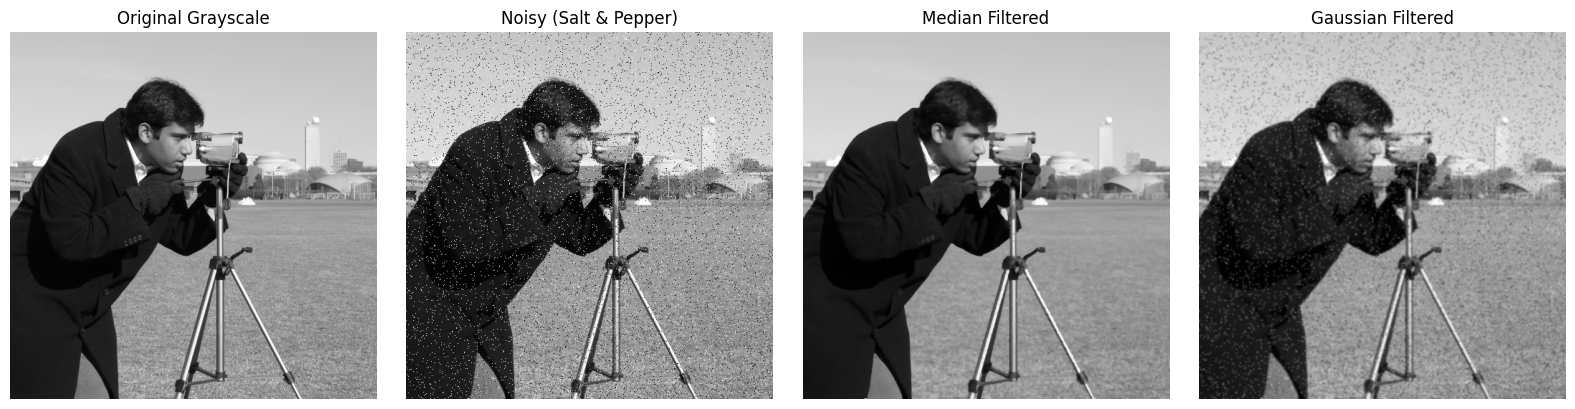

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# 1. Ambil citra grayscale dan ubah ke float
image = data.camera()  # uint8
image_float = img_as_float(image)

# 2. Tambahkan noise salt-and-pepper
noisy_image = util.random_noise(image_float, mode='s&p', amount=0.05)

# 3. Filter Median
median_filtered = filters.median(noisy_image, morphology.disk(2))

# 4. Filter Gaussian (rata-rata halus)
gaussian_filtered = filters.gaussian(noisy_image, sigma=1)

# 5. Tampilkan hasil
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image_float, cmap='gray')
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(noisy_image, cmap='gray')
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(median_filtered, cmap='gray')
axes[2].set_title("Median Filtered")
axes[2].axis('off')

axes[3].imshow(gaussian_filtered, cmap='gray')
axes[3].set_title("Gaussian Filtered")
axes[3].axis('off')

plt.tight_layout()
plt.show()
